#**Manasi Gopale**


In [1]:
"""Mount Drive and load the data"""
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
pd.set_option('display.max_columns', None)

DATA_PATH = '/content/drive/MyDrive/Retail_Sales_Analytics/data/SampleSuperstore.csv'
df = pd.read_csv(DATA_PATH, encoding='latin1')
df.head()

Mounted at /content/drive


,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


#**PHASE 1: Data Understanding**

In [2]:
df.shape

(9994, 13)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   object 
 1   Segment       9994 non-null   object 
 2   Country       9994 non-null   object 
 3   City          9994 non-null   object 
 4   State         9994 non-null   object 
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   object 
 7   Category      9994 non-null   object 
 8   Sub-Category  9994 non-null   object 
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1015.1+ KB


In [4]:
df.describe()

,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,55190.379428,229.858001,3.789574,0.156203,28.656896
std,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,90008.000000,209.940000,5.000000,0.200000,29.364000
max,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [5]:
df.isnull().sum()

,0
Ship Mode,0
Segment,0
Country,0
City,0
State,0
Postal Code,0
Region,0
Category,0
Sub-Category,0
Sales,0


In [6]:
df.duplicated().sum()

np.int64(17)

In [7]:
for col in ['Ship Mode', 'Segment', 'Region', 'Category', 'Sub-Category', 'State']:
    print(f"\n{col} ({df[col].nunique()} unique values):")
    print(df[col].unique())


Ship Mode (4 unique values):
['Second Class' 'Standard Class' 'First Class' 'Same Day']

Segment (3 unique values):
['Consumer' 'Corporate' 'Home Office']

Region (4 unique values):
['South' 'West' 'Central' 'East']

Category (3 unique values):
['Furniture' 'Office Supplies' 'Technology']

Sub-Category (17 unique values):
['Bookcases' 'Chairs' 'Labels' 'Tables' 'Storage' 'Furnishings' 'Art'
 'Phones' 'Binders' 'Appliances' 'Paper' 'Accessories' 'Envelopes'
 'Fasteners' 'Supplies' 'Machines' 'Copiers']

State (49 unique values):
['Kentucky' 'California' 'Florida' 'North Carolina' 'Washington' 'Texas'
 'Wisconsin' 'Utah' 'Nebraska' 'Pennsylvania' 'Illinois' 'Minnesota'
 'Michigan' 'Delaware' 'Indiana' 'New York' 'Arizona' 'Virginia'
 'Tennessee' 'Alabama' 'South Carolina' 'Oregon' 'Colorado' 'Iowa' 'Ohio'
 'Missouri' 'Oklahoma' 'New Mexico' 'Louisiana' 'Connecticut' 'New Jersey'
 'Massachusetts' 'Georgia' 'Nevada' 'Rhode Island' 'Mississippi'
 'Arkansas' 'Montana' 'New Hampshire' 'Maryl

In [8]:
df['State'].value_counts()

,count
State,
California,2001
New York,1128
Texas,985
Pennsylvania,587
Washington,506
Illinois,492
Ohio,469
Florida,383
Michigan,255


In [9]:
df['Category'].value_counts()

,count
Category,
Office Supplies,6026
Furniture,2121
Technology,1847


#**PHASE 2: Data Cleaning**

In [10]:
print("Before:", df.shape)
df = df.drop_duplicates()
print("After:", df.shape)

Before: (9994, 13)
After: (9977, 13)


In [11]:
df = df.drop_duplicates().copy()

In [12]:
df = pd.read_csv(DATA_PATH, encoding='latin1').copy()

In [13]:
df['Postal Code'] = df['Postal Code'].astype(str)

In [14]:
df['Region'].unique()

array(['South', 'West', 'Central', 'East'], dtype=object)

In [15]:
df['Segment'].unique()

array(['Consumer', 'Corporate', 'Home Office'], dtype=object)

In [16]:
df['Ship Mode'].unique()

array(['Second Class', 'Standard Class', 'First Class', 'Same Day'],
      dtype=object)

#**Phase 3: **Feature** engineering**

In [17]:
df['Profit Margin (%)'] = (df['Profit'] / df['Sales']) * 100

df['Profit Flag'] = np.where(df['Profit'] < 0, 'Loss', 'Profit')

df['Discount Band'] = pd.cut(
    df['Discount'],
    bins=[-0.01, 0, 0.2, 0.4, 1],
    labels=['No Discount', 'Low (0-20%)', 'Medium (20-40%)', 'High (40%+)']
)

In [18]:
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit,Profit Margin (%),Profit Flag,Discount Band
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136,16.00,Profit,No Discount
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820,30.00,Profit,No Discount
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714,47.00,Profit,No Discount
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310,-40.00,Loss,High (40%+)
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164,11.25,Profit,Low (0-20%)


In [19]:
CLEAN_PATH = '/content/drive/MyDrive/Retail_Sales_Analytics/data/Superstore_Cleaned.csv'
df.to_csv(CLEAN_PATH, index=False)

#**PHASE 4: Exploratory Data Analysis**

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
print("Total Sales:", round(df['Sales'].sum(), 2))
print("Total Profit:", round(df['Profit'].sum(), 2))
print("Overall Profit Margin %:", round((df['Profit'].sum() / df['Sales'].sum()) * 100, 2))

Total Sales: 2297200.86
Total Profit: 286397.02
Overall Profit Margin %: 12.47


In [22]:
category_summary = df.groupby('Category')[['Sales', 'Profit']].sum().sort_values('Sales', ascending=False)
category_summary

,Sales,Profit
Category,,
Technology,836154.0330,145454.9481
Furniture,741999.7953,18451.2728
Office Supplies,719047.0320,122490.8008


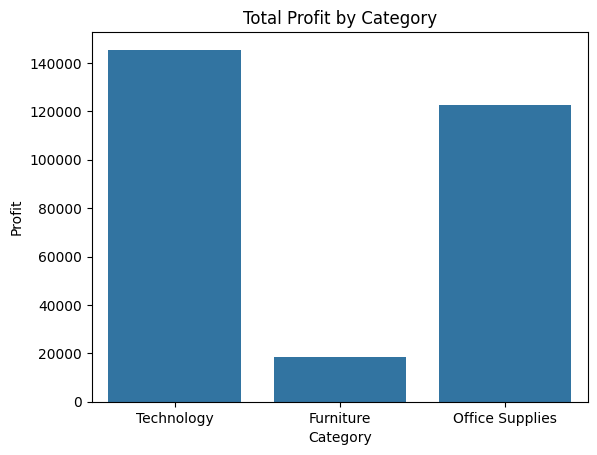

In [23]:
sns.barplot(data=category_summary.reset_index(), x='Category', y='Profit')
plt.title('Total Profit by Category')
plt.show()

In [24]:
subcat_summary = df.groupby('Sub-Category')[['Sales', 'Profit']].sum().sort_values('Profit')
subcat_summary

,Sales,Profit
Sub-Category,,
Tables,206965.5320,-17725.4811
Bookcases,114879.9963,-3472.5560
Supplies,46673.5380,-1189.0995
Fasteners,3024.2800,949.5182
Machines,189238.6310,3384.7569
Labels,12486.3120,5546.2540
Art,27118.7920,6527.7870
Envelopes,16476.4020,6964.1767
Furnishings,91705.1640,13059.1436


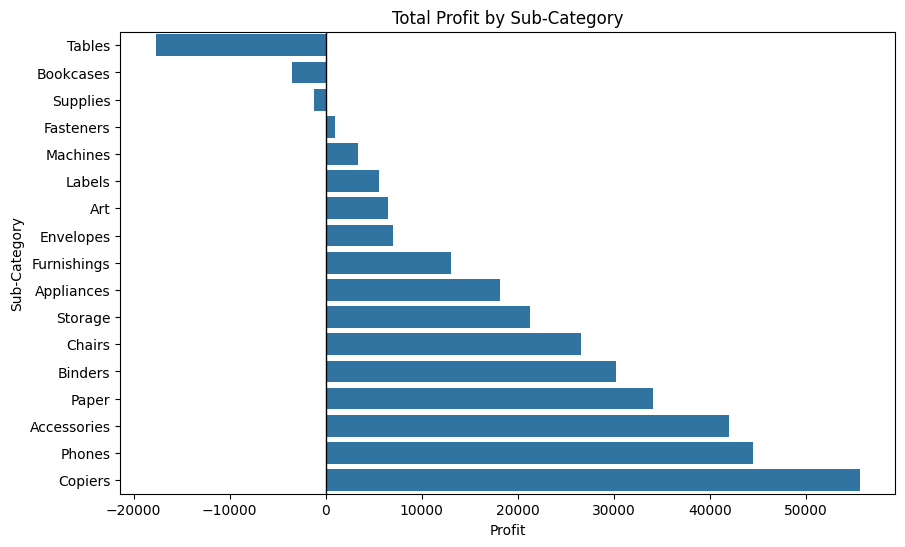

In [25]:
plt.figure(figsize=(10,6))
sns.barplot(data=subcat_summary.reset_index(), y='Sub-Category', x='Profit')
plt.title('Total Profit by Sub-Category')
plt.axvline(0, color='black', linewidth=1)
plt.show()

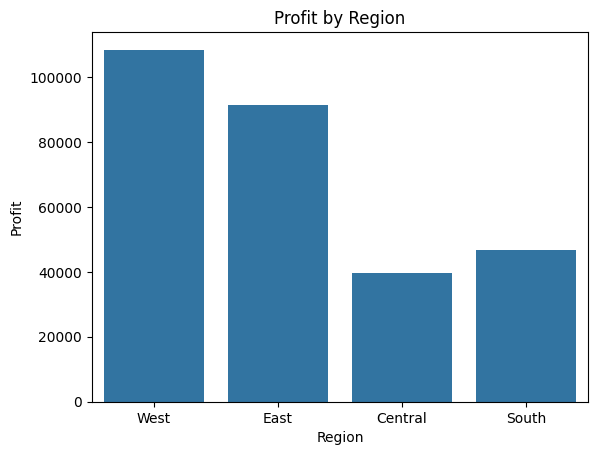

In [26]:
region_summary = df.groupby('Region')[['Sales', 'Profit']].sum().sort_values('Sales', ascending=False)
sns.barplot(data=region_summary.reset_index(), x='Region', y='Profit')
plt.title('Profit by Region')
plt.show()

In [27]:
state_profit = df.groupby('State')['Profit'].sum().sort_values()
print("Bottom 10 States:")
print(state_profit.head(10))
print("\nTop 10 States:")
print(state_profit.tail(10))

Bottom 10 States:
State
Texas            -25729.3563
Ohio             -16971.3766
Pennsylvania     -15559.9603
Illinois         -12607.8870
North Carolina    -7490.9122
Colorado          -6527.8579
Tennessee         -5341.6936
Arizona           -3427.9246
Florida           -3399.3017
Oregon            -1190.4705
Name: Profit, dtype: float64

Top 10 States:
State
Delaware       9977.3748
Minnesota     10823.1874
Kentucky      11199.6966
Georgia       16250.0433
Indiana       18382.9363
Virginia      18597.9504
Michigan      24463.1876
Washington    33402.6517
New York      74038.5486
California    76381.3871
Name: Profit, dtype: float64


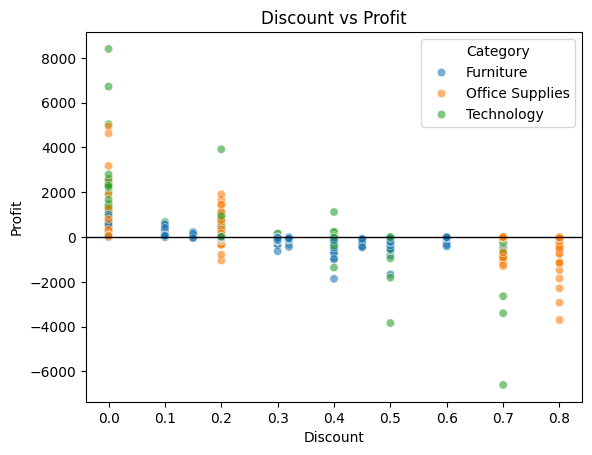

In [28]:
sns.scatterplot(data=df, x='Discount', y='Profit', hue='Category', alpha=0.6)
plt.axhline(0, color='black', linewidth=1)
plt.title('Discount vs Profit')
plt.show()

In [29]:
df.groupby('Discount Band')['Profit'].mean()

/tmp/ipykernel_3370/2971374333.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Discount Band')['Profit'].mean()


,Profit
Discount Band,
No Discount,66.900292
Low (0-20%),26.501571
Medium (20-40%),-77.864055
High (40%+),-106.708028


In [30]:
segment_summary = df.groupby('Segment')[['Sales', 'Profit']].sum()
segment_summary

,Sales,Profit
Segment,,
Consumer,1.161401e+06,134119.2092
Corporate,7.061464e+05,91979.1340
Home Office,4.296531e+05,60298.6785


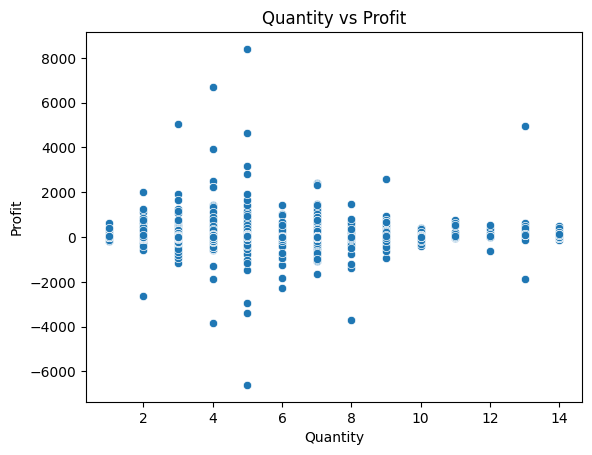

In [31]:
sns.scatterplot(data=df, x='Quantity', y='Profit')
plt.title('Quantity vs Profit')
plt.show()

#**PHASE 5: SQL Analysis**

In [32]:
import sqlite3
conn = sqlite3.connect('superstore.db')
df.to_sql('superstore', conn, if_exists='replace', index=False)

9994

In [33]:
query = """
SELECT Category, SUM(Sales) AS Total_Sales, SUM(Profit) AS Total_Profit
FROM superstore
GROUP BY Category
ORDER BY Total_Sales DESC;
"""
pd.read_sql_query(query, conn)

,Category,Total_Sales,Total_Profit
0,Technology,836154.0330,145454.9481
1,Furniture,741999.7953,18451.2728
2,Office Supplies,719047.0320,122490.8008


In [34]:
query = """
SELECT * FROM superstore WHERE Region = 'West' LIMIT 10;
"""
pd.read_sql_query(query, conn)

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit,Profit Margin (%),Profit Flag,Discount Band
0,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.620,2,0.0,6.8714,47.00,Profit,No Discount
1,Standard Class,Consumer,United States,Los Angeles,California,90032,West,Furniture,Furnishings,48.860,7,0.0,14.1694,29.00,Profit,No Discount
2,Standard Class,Consumer,United States,Los Angeles,California,90032,West,Office Supplies,Art,7.280,4,0.0,1.9656,27.00,Profit,No Discount
3,Standard Class,Consumer,United States,Los Angeles,California,90032,West,Technology,Phones,907.152,6,0.2,90.7152,10.00,Profit,Low (0-20%)
4,Standard Class,Consumer,United States,Los Angeles,California,90032,West,Office Supplies,Binders,18.504,3,0.2,5.7825,31.25,Profit,Low (0-20%)
5,Standard Class,Consumer,United States,Los Angeles,California,90032,West,Office Supplies,Appliances,114.900,5,0.0,34.4700,30.00,Profit,No Discount
6,Standard Class,Consumer,United States,Los Angeles,California,90032,West,Furniture,Tables,1706.184,9,0.2,85.3092,5.00,Profit,Low (0-20%)
7,Standard Class,Consumer,United States,Los Angeles,California,90032,West,Technology,Phones,911.424,4,0.2,68.3568,7.50,Profit,Low (0-20%)
8,Standard Class,Consumer,United States,Seattle,Washington,98103,West,Office Supplies,Binders,407.976,3,0.2,132.5922,32.50,Profit,Low (0-20%)
9,Second Class,Consumer,United States,West Jordan,Utah,84084,West,Office Supplies,Storage,55.500,2,0.0,9.9900,18.00,Profit,No Discount


In [35]:
query = """
SELECT "Sub-Category", SUM(Sales) AS Total_Sales, SUM(Profit) AS Total_Profit
FROM superstore
GROUP BY "Sub-Category"
ORDER BY Total_Profit ASC;
"""
pd.read_sql_query(query, conn)

,Sub-Category,Total_Sales,Total_Profit
0,Tables,206965.5320,-17725.4811
1,Bookcases,114879.9963,-3472.5560
2,Supplies,46673.5380,-1189.0995
3,Fasteners,3024.2800,949.5182
4,Machines,189238.6310,3384.7569
5,Labels,12486.3120,5546.2540
6,Art,27118.7920,6527.7870
7,Envelopes,16476.4020,6964.1767
8,Furnishings,91705.1640,13059.1436
9,Appliances,107532.1610,18138.0054


In [36]:
query = """
SELECT State,
       CASE WHEN Profit < 0 THEN 'Loss' ELSE 'Profit' END AS Status,
       Profit
FROM superstore
ORDER BY Profit ASC
LIMIT 10;
"""
pd.read_sql_query(query, conn)

,State,Status,Profit
0,Ohio,Loss,-6599.9780
1,North Carolina,Loss,-3839.9904
2,Texas,Loss,-3701.8928
3,Colorado,Loss,-3399.9800
4,Illinois,Loss,-2929.4845
5,Ohio,Loss,-2639.9912
6,Texas,Loss,-2287.7820
7,North Carolina,Loss,-1862.3124
8,Texas,Loss,-1850.9464
9,Florida,Loss,-1811.0784


In [37]:
query = """
SELECT Category, AVG(Discount) AS Avg_Discount
FROM superstore
GROUP BY Category
HAVING AVG(Discount) > 0.15;
"""
pd.read_sql_query(query, conn)

,Category,Avg_Discount
0,Furniture,0.173923
1,Office Supplies,0.157285


In [38]:
query = """SELECT Category, "Sub-Category", SUM(Profit) AS Total_Profit,
       RANK() OVER (PARTITION BY Category ORDER BY SUM(Profit) DESC) AS Rank_In_Category
FROM superstore
GROUP BY Category, "Sub-Category";"""
pd.read_sql_query(query, conn)

,Category,Sub-Category,Total_Profit,Rank_In_Category
0,Furniture,Chairs,26590.1663,1
1,Furniture,Furnishings,13059.1436,2
2,Furniture,Bookcases,-3472.5560,3
3,Furniture,Tables,-17725.4811,4
4,Office Supplies,Paper,34053.5693,1
5,Office Supplies,Binders,30221.7633,2
6,Office Supplies,Storage,21278.8264,3
7,Office Supplies,Appliances,18138.0054,4
8,Office Supplies,Envelopes,6964.1767,5
9,Office Supplies,Art,6527.7870,6


In [39]:
query = """WITH state_profit AS (
    SELECT State, SUM(Profit) AS Total_Profit
    FROM superstore
    GROUP BY State
)
SELECT * FROM state_profit
WHERE Total_Profit < 0
ORDER BY Total_Profit ASC;"""
pd.read_sql_query(query, conn)

,State,Total_Profit
0,Texas,-25729.3563
1,Ohio,-16971.3766
2,Pennsylvania,-15559.9603
3,Illinois,-12607.8870
4,North Carolina,-7490.9122
5,Colorado,-6527.8579
6,Tennessee,-5341.6936
7,Arizona,-3427.9246
8,Florida,-3399.3017
9,Oregon,-1190.4705


In [40]:
query = """SELECT
  CASE
    WHEN Discount = 0 THEN 'No Discount'
    WHEN Discount <= 0.2 THEN 'Low (0-20%)'
    WHEN Discount <= 0.4 THEN 'Medium (20-40%)'
    ELSE 'High (40%+)'
  END AS Discount_Band,
  AVG(Profit) AS Avg_Profit,
  COUNT(*) AS Num_Orders
FROM superstore
GROUP BY Discount_Band;"""
pd.read_sql_query(query, conn)

,Discount_Band,Avg_Profit,Num_Orders
0,High (40%+),-106.708028,933
1,Low (0-20%),26.501571,3803
2,Medium (20-40%),-77.864055,460
3,No Discount,66.900292,4798
